# Food Inspections — Análise Exploratória
## 1 · Estrutura — *de que são feitos estes dados?*

Inspeções sanitárias em estabelecimentos de alimentação da cidade de Chicago
(*Chicago Food Inspections*, portal de dados aberto da prefeitura).
Cada linha é **uma inspeção**, não um estabelecimento — o mesmo restaurante aparece
várias vezes ao longo dos anos.

Na etapa de estrutura, analisamos **quais são os tipos** e **quantos valores distintos** cada coluna tem.

> 📋 **Passo zero: o dicionário de dados.** As descrições abaixo vêm dos nomes das colunas
> e dos valores observados no próprio arquivo — o dicionário oficial está na página do
> dataset no Chicago Data Portal e deve ser conferido antes de fechar o relatório.
>
> | coluna | em português |
> |---|---|
> | `Inspection ID` | número da inspeção |
> | `DBA Name` · `AKA Name` | razão social (*doing business as*) · nome de fachada |
> | `License #` | número da licença do estabelecimento |
> | `Facility Type` | tipo de estabelecimento (restaurante, mercado, escola…) |
> | `Risk` | classificação de risco sanitário (1 alto · 2 médio · 3 baixo) |
> | `Address` · `City` · `State` · `Zip` | endereço · cidade · estado · CEP |
> | `Inspection Date` | data da inspeção |
> | `Inspection Type` | motivo da inspeção (rotina, licença, denúncia…) |
> | `Results` | **resultado da inspeção** — o alvo natural do projeto |
> | `Violations` | texto livre com as violações encontradas |
> | `Latitude` · `Longitude` · `Location` | coordenadas · o par (lat, lon) já formatado |

In [ ]:
import hashlib, json
from pathlib import Path
import pandas as pd

# --- extração congelada ---------------------------------------------------
# O portal de Chicago recebe inspeções novas todo dia: rebaixar o CSV muda a
# base no meio da análise (já vimos 315.488, 315.560 e 315.963 linhas em
# execuções diferentes). Por isso o notebook lê UMA extração fixa, identificada
# pela data, e nunca o endpoint ao vivo.
EXTRACAO  = "2026-09-24"
DADOS     = Path("dados")
CSV       = DADOS / f"food_inspections_{EXTRACAO}.csv"
GZ        = DADOS / f"food_inspections_{EXTRACAO}.csv.gz"
MANIFESTO = DADOS / f"food_inspections_{EXTRACAO}.json"

# fallback para o Colab ou outra máquina: o mesmo arquivo publicado como release
# TODO: trocar <seu-usuario>/<repo> depois de publicar a release
URL_CONGELADA = (
    "https://github.com/<seu-usuario>/<repo>/releases/download/"
    f"dados-{EXTRACAO}/food_inspections_{EXTRACAO}.csv.gz"
)

fonte = next((p for p in (CSV, GZ) if p.exists()), URL_CONGELADA)
print("lendo de:", fonte)

df = pd.read_csv(fonte, low_memory=False)   # o gzip é inferido pela extensão .gz

# --- trava: é mesmo a base que gerou os números do relatório? --------------
if MANIFESTO.exists():
    m = json.loads(MANIFESTO.read_text(encoding="utf-8"))
    assert df.shape == (m["linhas"], m["colunas"]), (
        f"base divergente: o manifesto da extração {EXTRACAO} registra "
        f"{m['linhas']:,} x {m['colunas']}, mas o arquivo lido tem "
        f"{df.shape[0]:,} x {df.shape[1]}. Os números do relatório não valem "
        "para este arquivo."
    )
    print(f"extração {EXTRACAO} conferida · {m['linhas']:,} linhas × "
          f"{m['colunas']} colunas · sha {m['arquivos']['csv']['sha256'][:12]}…")
else:
    print("⚠ manifesto ausente: a base não pôde ser conferida.")

print(df.shape)
df.head()

Esse dataset possui **315.488 linhas e 17 colunas.**

In [ ]:
df.info(verbose=True)     # tipo de cada coluna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315560 entries, 0 to 315559
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Inspection ID    315560 non-null  int64  
 1   DBA Name         315560 non-null  object 
 2   AKA Name         313137 non-null  object 
 3   License #        315541 non-null  float64
 4   Facility Type    310219 non-null  object 
 5   Risk             315473 non-null  object 
 6   Address          315560 non-null  object 
 7   City             315379 non-null  object 
 8   State            315485 non-null  object 
 9   Zip              315518 non-null  float64
 10  Inspection Date  315560 non-null  object 
 11  Inspection Type  315559 non-null  object 
 12  Results          315560 non-null  object 
 13  Violations       226610 non-null  object 
 14  Latitude         314515 non-null  float64
 15  Longitude        314515 non-null  float64
 16  Location         314515 non-null  obje

In [ ]:
df.dtypes.value_counts()        # quantas colunas de cada tipo

,count
object,12
float64,4
int64,1


**12 colunas de texto, 4 decimais e 1 inteira**

In [ ]:
cardinalidade = df.nunique().sort_values()     # quantos valores DIFERENTES cada coluna tem, sabendo que o dataset tem 315.488 linhas
cardinalidade

,0
Risk,4
State,7
Results,7
City,94
Inspection Type,110
Zip,139
Facility Type,527
Inspection Date,4207
Longitude,18946
Latitude,18946


### 📌 Primeiro achado — `Inspection ID`

`Inspection ID` tem **315.488 valores distintos**, exatamente o número de linhas. Isso **levanta a suspeita** de identificador — mas não prova. Então, agora vamos provar isso:

In [ ]:
print(df["Inspection ID"].head(3).tolist(), "...", df["Inspection ID"].tail(3).tolist())
print("mínimo:", df["Inspection ID"].min(), "| máximo:", df["Inspection ID"].max())

# é a sequência 1, 2, 3, ...?
seq = range(1, len(df) + 1)
print("é 1..n?", (df["Inspection ID"].sort_values().reset_index(drop=True) == seq).all())

[1068208, 1072213, 1072214] ... [2641591, 2641585, 2640587]
mínimo: 44247 | máximo: 2642757
é 1..n? False


**Não é a sequência 1..n** — vai de **44.247 a 2.642.696**, com buracos. Mesmo assim é identificador: um contador da prefeitura, com buracos porque nem toda inspeção emitida entra neste arquivo. Não tem unidade nem significado próprio.

→ **Decisão:** descartar como variável preditora; manter como **chave** para rastrear a linha até a fonte.

### 📌 O segundo achado — a coluna que parece ID mas não é

`License #` tem **49.093 valores distintos** em 315.488 linhas. Não é chave da linha —
é a chave do **estabelecimento**. É ela que responde "esta é a mesma padaria de 2019?".

In [ ]:
por_licenca = df["License #"].value_counts()
print("inspeções por licença — mediana:", por_licenca.median(),
      "| máximo:", por_licenca.max())
print("linhas com License # == 0:", (df["License #"] == 0).sum())
print("linhas com License # vazio:", df["License #"].isna().sum())

inspeções por licença — mediana: 3.0 | máximo: 831
linhas com License # == 0: 831
linhas com License # vazio: 19


Mediana de **3 inspeções por licença**. Mas o "máximo" de **831** é a licença **`0`** —
que não é uma licença, é um preenchimento para *"sem licença"*. Juntar essas 831 linhas
como se fossem o mesmo estabelecimento seria erro.

→ **Decisão:** tratar `License #` como **texto** (é código, não número) e `0` como ausente.

📌 Estrutura já entrega uma consequência de modelagem: com o mesmo estabelecimento repetido
em várias linhas, uma divisão treino/teste aleatória **vaza informação** de um lado para o
outro. A divisão tem de ser por licença ou por data.

### As colunas categóricas

Cinco colunas têm cardinalidade baixa o bastante para caber num `value_counts`. São elas
que descrevem a inspeção.

In [ ]:
for c in ["Risk", "Results", "State", "Inspection Type", "Facility Type"]:
    print(f"--- {c}  ({df[c].nunique()} valores distintos)")
    print(df[c].value_counts(dropna=False).head(6), end="\n\n")

--- Risk  (4 valores distintos)
Risk
Risk 1 (High)      234769
Risk 2 (Medium)     56107
Risk 3 (Low)        24512
NaN                    87
All                    85
Name: count, dtype: int64

--- Results  (7 valores distintos)
Results
Pass                  163310
Fail                   60774
Pass w/ Conditions     46822
Out of Business        25851
No Entry               14116
Not Ready               4592
Name: count, dtype: int64

--- State  (7 valores distintos)
State
IL     315461
NaN        75
IN         13
CA          5
WI          3
DC          1
Name: count, dtype: int64

--- Inspection Type  (110 valores distintos)
Inspection Type
Canvass                    162938
License                     42358
Canvass Re-Inspection       35168
Complaint                   29907
License Re-Inspection       12815
Complaint Re-Inspection     12512
Name: count, dtype: int64

--- Facility Type  (527 valores distintos)
Facility Type
Restaurant                      214129
Grocery Store           

Três leituras, e cada uma vira decisão:

- **`Results` (7 valores)** é o alvo natural — mas não é um sim/não. `Out of Business`,
  `No Entry`, `Not Ready` e `Business Not Located` (cerca de 44,6 mil linhas somadas)
  descrevem uma inspeção que **não aconteceu**. → **Decisão:** definir o alvo explicitamente;
  provavelmente `Pass`/`Pass w/ Conditions`/`Fail` e o resto fora.
- **`Risk` (4 valores)** é **ordinal** disfarçado de texto: alto > médio > baixo. O quarto
  valor é `All`, com 86 linhas — não pertence à escala. → **Decisão:** codificar a ordem 1‑2‑3
  e tratar `All` à parte.
- **`Facility Type` (527 valores)** tem cauda longa: `Restaurant` é 68% das linhas e centenas
  de tipos aparecem meia dúzia de vezes, com grafias livres. → **Decisão:** agrupar os raros
  em `Outros`.

E `State`: **315.389 de 315.488 linhas são `IL`**. Uma coluna praticamente constante não
distingue nada. → **Decisão:** descartar (as poucas linhas fora de IL são suspeitas de erro
de digitação, a conferir no passo de qualidade).

In [ ]:
df["City"].value_counts(dropna=False).head(8)

,count
City,
CHICAGO,314253
Chicago,535
NaN,181
chicago,173
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
CHicago,22


`City` tem **94 valores distintos** — mas não são 94 cidades. `CHICAGO`, `Chicago`,
`chicago`, `CHicago`, `CCHICAGO`, `CHICAGOCHICAGO`… são a mesma cidade escrita de jeitos
diferentes.

📌 **A cardinalidade fez a pergunta certa de novo.** 94 é alto demais para um dataset de
uma cidade só — e olhar os valores mostra por quê.

→ **Decisão:** precisamos normalizar (maiúsculas, espaços) antes de qualquer contagem por cidade.

### Os tipos que mentem

`df.info()` mostra o tipo que o pandas **adivinhou** — e ele erra quando o dado é código
ou data guardados como número/texto.

In [ ]:
print("Zip             ->", df["Zip"].dtype, "| ex.:", df["Zip"].dropna().head(2).tolist())
print("Inspection Date ->", df["Inspection Date"].dtype, "| ex.:", df["Inspection Date"].head(2).tolist())
print("Location        ->", df["Location"].dtype, "| ex.:", df["Location"].head(1).tolist())

Zip             -> float64 | ex.: [60642.0, 60615.0]
Inspection Date -> object | ex.: ['03/14/2012', '10/22/2012']
Location        -> object | ex.: ['(41.902462266949634, -87.66530609467256)']


Três erros de tipo, três decisões:

| coluna | o pandas leu como | o que é | decisão |
|---|---|---|---|
| `Zip` | `float64` | **código** de CEP dos EUA (vira `60623.0`) | ler como texto |
| `Inspection Date` | texto | **data** | `pd.to_datetime(..., format="%m/%d/%Y")` |
| `Location` | texto | o par `(lat, lon)` que já existe em duas colunas | descartar (ver abaixo) |


In [ ]:
datas = pd.to_datetime(df["Inspection Date"], format="%m/%d/%Y", errors="coerce")
print("de", datas.min().date(), "até", datas.max().date(),
      "| falhas na conversão:", datas.isna().sum())

de 2010-01-04 até 2026-09-15 | falhas na conversão: 0


### A coluna redundante

`Location` parece uma terceira informação geográfica, já que sabemos que temos as colunas `Latitude` e `Longitude`. Então, com isso, vamos conferir:

In [ ]:
import numpy as np

com_coord = df.dropna(subset=["Location"])
partes = com_coord["Location"].str.strip("()").str.split(", ", expand=True).astype(float)

print("Location bate com Latitude :", np.isclose(partes[0], com_coord["Latitude"]).all())
print("Location bate com Longitude:", np.isclose(partes[1], com_coord["Longitude"]).all())
print("some junto com Latitude    :", (df["Location"].isna() == df["Latitude"].isna()).all())

Location bate com Latitude : True
Location bate com Longitude: True
some junto com Latitude    : True


**Bate nas três verificações.** `Location` é `Latitude` e `Longitude` coladas num texto —
e some exatamente nas mesmas 1.045 linhas.

→ **Decisão:** descartar `Location`.

### Visão geral da estrutura do dataset

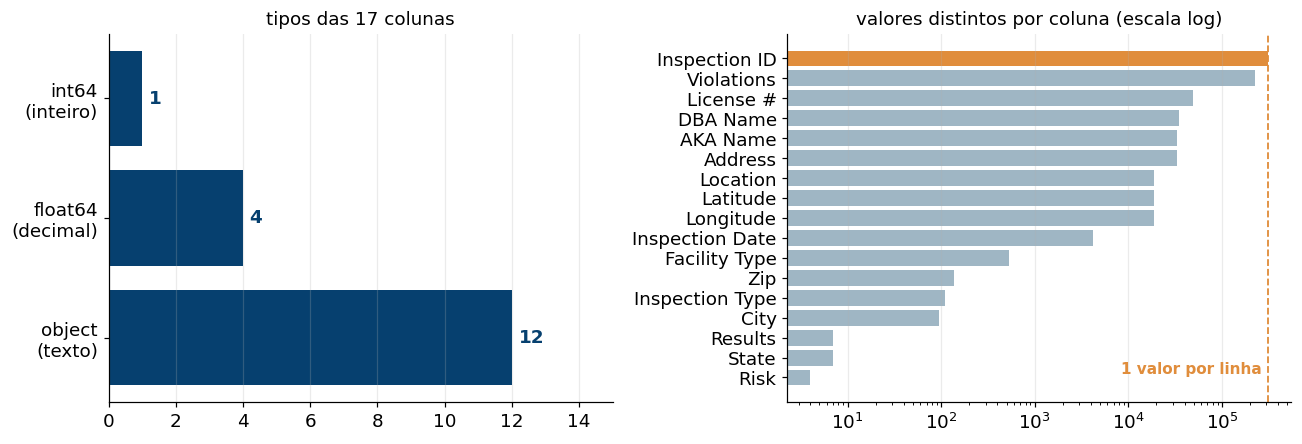

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figuras"); FIGS.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

tipos = df.dtypes.value_counts()
nomes = {"str": "texto", "object": "texto", "int64": "inteiro", "float64": "decimal"}
ax1.barh([f"{t}\n({nomes.get(str(t), '')})" for t in tipos.index], tipos.values, color="#06406F")
for i, v in enumerate(tipos.values):
    ax1.text(v + .2, i, str(v), va="center", color="#06406F", fontweight="bold")
ax1.set_xlim(0, 15); ax1.set_title("tipos das 17 colunas"); ax1.grid(axis="y", alpha=0)

# escala log: de 4 (Risk) a 315.488 (Inspection ID) não cabe em escala linear
card = df.nunique().sort_values()
cores = ["#E08D3C" if n == "Inspection ID" else "#9FB6C4" for n in card.index]
ax2.barh(card.index, card.values, color=cores)
ax2.set_xscale("log")
ax2.axvline(len(df), color="#E08D3C", ls="--", lw=1.2)
ax2.text(len(df) * .85, .2, "1 valor por linha", color="#E08D3C",
         fontweight="bold", ha="right", fontsize=10)
ax2.set_title("valores distintos por coluna (escala log)"); ax2.grid(axis="y", alpha=0)

plt.tight_layout()
plt.savefig(FIGS / "fi-01-estrutura.png", dpi=200, bbox_inches="tight")   # ANTES do show()
plt.show()

---
## Conclusão da Estrutura

- **315.488 linhas × 17 colunas**; 12 de texto, 4 decimais, 1 inteira;
- A unidade da linha é a **inspeção**, e não o estabelecimento.

| achado | decisão |
|---|---|
| `Inspection ID` tem 1 valor por linha (iniciando de 44.247–2.642.696, com buracos) | descartar como preditor; manter como chave |
| `License #` = 49.093 estabelecimentos em 315.488 linhas; `0` usado como "sem licença" (831 linhas) | ler como texto; `0` vira ausente; **dividir treino/teste por licença ou por data**, nunca aleatório |
| `Location` é `Latitude`+`Longitude` em texto | descartar |
| `State` é `IL` em 315.389 de 315.488 linhas | descartar (quase constante) |
| `Zip` lido como `float64`; `Inspection Date` lida como texto | ler CEP como texto; converter a data (`%m/%d/%Y`) — cobre 04/01/2010 a 14/09/2026 |
| `City` tem 94 valores para uma cidade só (`Chicago`, `chicago`, `CCHICAGO`…) | normalizar antes de agrupar |
| `Risk` é ordinal (alto/médio/baixo) + 86 linhas `All` | codificar a ordem; tratar `All` à parte |
| `Facility Type` tem 527 valores, `Restaurant` = 68% | agrupar a cauda em `Outros` |
| `Results` tem 7 valores, dos quais 4 (≈44,6 mil linhas) são "inspeção não realizada" | definir o alvo explicitamente antes de modelar |

---
## 2 · Qualidade — *dá para confiar?*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_q = df.copy(deep=True)

data_extracao = pd.Timestamp.today().normalize()

print(f"Linhas: {df_q.shape[0]:,}")
print(f"Colunas: {df_q.shape[1]}")
print(f"Data da análise: {data_extracao.date()}")

Linhas: 315,560
Colunas: 17
Data da análise: 2026-09-17


In [ ]:
resumo_vazios = pd.DataFrame({
    "faltantes": df_q.isna().sum(),
    "percentual_faltante": (df_q.isna().mean() * 100).round(2),
    "valores_distintos": df_q.nunique(dropna=True),
    "tipo_atual": df_q.dtypes.astype(str)
}).sort_values("faltantes", ascending=False)

colunas_com_vazio = resumo_vazios[
    resumo_vazios["faltantes"] > 0
]

display(colunas_com_vazio)

,faltantes,percentual_faltante,valores_distintos,tipo_atual
Violations,88950,28.19,224903,object
Facility Type,5341,1.69,527,object
AKA Name,2423,0.77,33430,object
Longitude,1045,0.33,18946,float64
Location,1045,0.33,18946,object
Latitude,1045,0.33,18946,float64
City,181,0.06,94,object
Risk,87,0.03,4,object
State,75,0.02,7,object
Zip,42,0.01,139,float64


In [ ]:
marcadores_de_vazio = {
    "",
    "nan",
    "null",
    "none",
    "n/a",
    "na",
    "unknown"
}

contagem_marcadores = {}

for coluna in df_q.select_dtypes(include="object").columns:
    valores = (
        df_q[coluna]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    contagem_marcadores[coluna] = int(
        valores.isin(marcadores_de_vazio).sum()
    )

marcadores_textuais = (
    pd.Series(
        contagem_marcadores,
        name="possiveis_vazios_escritos"
    )
    .sort_values(ascending=False)
)

display(
    marcadores_textuais[
        marcadores_textuais > 0
    ].to_frame()
)

,possiveis_vazios_escritos
DBA Name,3
Address,3


In [ ]:
duplicatas_exatas = int(df_q.duplicated().sum())

ids_repetidos = int(
    df_q["Inspection ID"]
    .duplicated(keep=False)
    .sum()
)

print("Linhas completamente idênticas:", duplicatas_exatas)
print("Linhas com Inspection ID repetido:", ids_repetidos)

Linhas completamente idênticas: 0
Linhas com Inspection ID repetido: 0


In [ ]:
licenca_valida = (
    df_q["License #"].notna()
    & df_q["License #"].ne(0)
)

chave_suspeita = [
    "License #",
    "Inspection Date",
    "Inspection Type"
]

mascara_suspeita = (
    licenca_valida
    & df_q.duplicated(chave_suspeita, keep=False)
)

possiveis_duplicatas = (
    df_q.loc[
        mascara_suspeita,
        [
            "Inspection ID",
            "License #",
            "DBA Name",
            "Inspection Date",
            "Inspection Type",
            "Results"
        ]
    ]
    .sort_values(chave_suspeita)
)

print(
    "Linhas com a mesma licença, data e tipo de inspeção:",
    len(possiveis_duplicatas)
)

display(possiveis_duplicatas.head(20))

Linhas com a mesma licença, data e tipo de inspeção: 2755


,Inspection ID,License #,DBA Name,Inspection Date,Inspection Type,Results
166687,1965749,241.0,HARD WATER BAR & GRILL,09/30/2016,Canvass,No Entry
167695,1965752,241.0,HOP HAUS ROGERS PARK,09/30/2016,Canvass,No Entry
229336,1092541,349.0,CLOVER CORP,08/09/2013,Canvass,Pass w/ Conditions
230645,1092549,349.0,KELLY'S PUB,08/09/2013,Canvass,Pass w/ Conditions
269076,543349,1362.0,MONTESSORI OF ENGLEWOOD,05/04/2011,Canvass,Pass
269536,166390,1362.0,JEWEL FOOD STORE #3232,05/04/2011,Canvass,Out of Business
33521,1965764,1392.0,JEWEL FOOD STORE #1296,09/30/2016,Complaint Re-Inspection,Fail
44484,1965672,1392.0,JEWEL FOOD STORE #1296,09/30/2016,Complaint Re-Inspection,Fail
125805,2129732,1491.0,BLACKIE'S,12/27/2017,Canvass,Out of Business
142342,2129733,1491.0,HALF SOUR,12/27/2017,Canvass,Pass w/ Conditions


In [ ]:
for coluna in ["Risk", "Results", "State"]:
    print(f"\n--- {coluna} ---")

    display(
        df_q[coluna]
        .value_counts(dropna=False)
        .rename("linhas")
        .to_frame()
    )


--- Risk ---


,linhas
Risk,
Risk 1 (High),234769
Risk 2 (Medium),56107
Risk 3 (Low),24512
NaN,87
All,85



--- Results ---


,linhas
Results,
Pass,163310
Fail,60774
Pass w/ Conditions,46822
Out of Business,25851
No Entry,14116
Not Ready,4592
Business Not Located,95



--- State ---


,linhas
State,
IL,315461
NaN,75
IN,13
CA,5
WI,3
DC,1
CO,1
NY,1


In [ ]:
cidade_normalizada = (
    df_q["City"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("Antes da normalização:")
display(
    df_q["City"]
    .value_counts(dropna=False)
    .head(15)
    .rename("linhas")
    .to_frame()
)

print("Depois de retirar espaços e padronizar maiúsculas:")
display(
    cidade_normalizada
    .value_counts(dropna=False)
    .head(15)
    .rename("linhas")
    .to_frame()
)

print(
    "Linhas com License # igual a zero:",
    int(df_q["License #"].eq(0).sum())
)

Antes da normalização:


,linhas
City,
CHICAGO,314253
Chicago,535
NaN,181
chicago,173
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
CHicago,22
MAYWOOD,15


Depois de retirar espaços e padronizar maiúsculas:


,linhas
City,
CHICAGO,314983
<NA>,181
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
MAYWOOD,16
ELK GROVE VILLAGE,13
CHICAGOCHICAGO,12
OAK PARK,12


Linhas com License # igual a zero: 831


In [ ]:
datas = pd.to_datetime(
    df_q["Inspection Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

zip_numerico = pd.to_numeric(
    df_q["Zip"],
    errors="coerce"
)

latitude = pd.to_numeric(
    df_q["Latitude"],
    errors="coerce"
)

longitude = pd.to_numeric(
    df_q["Longitude"],
    errors="coerce"
)

datas_invalidas = int(datas.isna().sum())

datas_futuras = int(
    (datas > data_extracao).sum()
)

zips_fora_do_dominio = int(
    (
        zip_numerico.notna()
        & (
            (zip_numerico < 10000)
            | (zip_numerico > 99999)
        )
    ).sum()
)

zips_com_decimal = int(
    (
        zip_numerico.notna()
        & (zip_numerico % 1 != 0)
    ).sum()
)

coordenadas_fora_do_dominio = int(
    (
        latitude.notna()
        & ~latitude.between(-90, 90)
    ).sum()
    +
    (
        longitude.notna()
        & ~longitude.between(-180, 180)
    ).sum()
)

coordenadas_parciais = int(
    (latitude.isna() ^ longitude.isna()).sum()
)

print("Menor data válida:", datas.min())
print("Maior data válida:", datas.max())
print("Datas inválidas:", datas_invalidas)
print("Datas futuras:", datas_futuras)
print("CEPs fora do intervalo de 5 dígitos:", zips_fora_do_dominio)
print("CEPs com parte decimal diferente de zero:", zips_com_decimal)
print("Coordenadas fora do domínio:", coordenadas_fora_do_dominio)
print("Linhas com apenas uma coordenada presente:", coordenadas_parciais)

Menor data válida: 2010-01-04 00:00:00
Maior data válida: 2026-09-15 00:00:00
Datas inválidas: 0
Datas futuras: 0
CEPs fora do intervalo de 5 dígitos: 0
CEPs com parte decimal diferente de zero: 0
Coordenadas fora do domínio: 0
Linhas com apenas uma coordenada presente: 0


In [ ]:
colunas_geograficas = [
    "Latitude",
    "Longitude",
    "Location"
]

padrao_geografico = (
    df_q[colunas_geograficas]
    .isna()
    .value_counts(dropna=False)
    .rename("linhas")
    .reset_index()
)

display(padrao_geografico)

,Latitude,Longitude,Location,linhas
0,False,False,False,314515
1,True,True,True,1045


In [ ]:
violacoes_por_resultado = (
    df_q.groupby(
        "Results",
        dropna=False
    )
    .agg(
        linhas=("Inspection ID", "size"),
        violacoes_faltantes=(
            "Violations",
            lambda serie: serie.isna().sum()
        ),
        percentual_sem_violacoes=(
            "Violations",
            lambda serie: round(
                serie.isna().mean() * 100,
                2
            )
        )
    )
    .sort_values("linhas", ascending=False)
)

display(violacoes_por_resultado)

,linhas,violacoes_faltantes,percentual_sem_violacoes
Results,,,
Pass,163310,40602,24.86
Fail,60774,3647,6.00
Pass w/ Conditions,46822,948,2.02
Out of Business,25851,25807,99.83
No Entry,14116,13341,94.51
Not Ready,4592,4510,98.21
Business Not Located,95,95,100.00


In [ ]:
decisoes_qualidade = pd.DataFrame([
    {
        "problema": "License # igual a zero",
        "interpretacao": "Código usado para estabelecimento sem licença",
        "decisao_prevista": "Converter zero para ausente e tratar a coluna como identificador"
    },
    {
        "problema": "Grafias diferentes em City",
        "interpretacao": "Diferenças de maiúsculas e espaços",
        "decisao_prevista": "Remover espaços e converter o texto para maiúsculas"
    },
    {
        "problema": "Zip armazenado como decimal",
        "interpretacao": "CEP é código, não medida numérica",
        "decisao_prevista": "Validar e converter para texto"
    },
    {
        "problema": "Location repete latitude e longitude",
        "interpretacao": "Informação geográfica redundante",
        "decisao_prevista": "Manter latitude e longitude e descartar Location"
    },
    {
        "problema": "Risk com All ou ausente",
        "interpretacao": "Valores fora da escala Risk 1, Risk 2 e Risk 3",
        "decisao_prevista": "Investigar e tratar separadamente; não imputar automaticamente"
    },
    {
        "problema": "Results sem inspeção sanitária concluída",
        "interpretacao": "Out of Business, No Entry, Not Ready e Business Not Located não são aprovação ou falha",
        "decisao_prevista": "Excluir da definição do alvo após decisão do grupo"
    },
    {
        "problema": "Possíveis duplicatas",
        "interpretacao": "Repetição pode ser erro ou inspeção legítima",
        "decisao_prevista": "Remover somente duplicatas comprovadas"
    }
])

display(decisoes_qualidade)

,problema,interpretacao,decisao_prevista
0,License # igual a zero,Código usado para estabelecimento sem licença,Converter zero para ausente e tratar a coluna ...
1,Grafias diferentes em City,Diferenças de maiúsculas e espaços,Remover espaços e converter o texto para maiús...
2,Zip armazenado como decimal,"CEP é código, não medida numérica",Validar e converter para texto
3,Location repete latitude e longitude,Informação geográfica redundante,Manter latitude e longitude e descartar Location
4,Risk com All ou ausente,"Valores fora da escala Risk 1, Risk 2 e Risk 3",Investigar e tratar separadamente; não imputar...
5,Results sem inspeção sanitária concluída,"Out of Business, No Entry, Not Ready e Busines...",Excluir da definição do alvo após decisão do g...
6,Possíveis duplicatas,Repetição pode ser erro ou inspeção legítima,Remover somente duplicatas comprovadas


In [ ]:
print("CONCLUSÃO DA QUALIDADE")
print("-" * 50)

print(
    f"{len(colunas_com_vazio)} das {df_q.shape[1]} colunas "
    "possuem pelo menos um valor ausente."
)

print(
    f"Foram encontradas {duplicatas_exatas} linhas "
    "completamente idênticas."
)

print(
    f"Foram encontradas {ids_repetidos} linhas com "
    "Inspection ID repetido."
)

print(
    f"Existem {len(possiveis_duplicatas)} linhas com a mesma "
    "licença, data e tipo de inspeção; elas precisam ser "
    "investigadas antes de qualquer remoção."
)

print(
    f"Existem {datas_invalidas} datas que não puderam ser "
    "convertidas e {datas_futuras} datas futuras."
)

print(
    "\nAs principais necessidades previstas são: normalizar "
    "categorias de texto, converter CEP e licença para códigos, "
    "investigar os mecanismos dos valores ausentes e remover "
    "somente duplicatas comprovadas."
)

CONCLUSÃO DA QUALIDADE
--------------------------------------------------
12 das 17 colunas possuem pelo menos um valor ausente.
Foram encontradas 0 linhas completamente idênticas.
Foram encontradas 0 linhas com Inspection ID repetido.
Existem 2755 linhas com a mesma licença, data e tipo de inspeção; elas precisam ser investigadas antes de qualquer remoção.
Existem 0 datas que não puderam ser convertidas e {datas_futuras} datas futuras.

As principais necessidades previstas são: normalizar categorias de texto, converter CEP e licença para códigos, investigar os mecanismos dos valores ausentes e remover somente duplicatas comprovadas.


### Conclusão da qualidade

O dataset possui 315.560 inspeções e apresenta boa integridade estrutural: não foram encontradas linhas completamente duplicadas, `Inspection ID` repetidos, datas inválidas, datas futuras, CEPs impossíveis ou coordenadas fora do domínio.

Das 17 colunas, 12 apresentam algum valor ausente. A maior ausência está em `Violations`, com 88.950 linhas (28,19%). Essa ausência não ocorre ao acaso: ela está presente em quase todos os registros nos quais a inspeção não foi concluída, mas em apenas 6% dos resultados `Fail` e 2,02% dos resultados `Pass w/ Conditions`. Portanto, em muitos casos o vazio significa “não se aplica”, e não perda aleatória de informação.

`Facility Type` possui 5.341 ausências (1,69%) e deverá ser investigada antes de qualquer preenchimento. `AKA Name` pode estar ausente simplesmente porque o estabelecimento não possui nome alternativo. As 1.045 ausências de `Latitude`, `Longitude` e `Location` ocorrem exatamente nas mesmas linhas, indicando um único problema de geocodificação.

Foram encontradas 2.755 linhas com a mesma licença, data e tipo de inspeção. Como não existem linhas idênticas nem `Inspection ID` repetidos, esses casos não serão removidos automaticamente: podem representar inspeções legítimas ou estabelecimentos diferentes associados à mesma licença.

Também foram encontradas inconsistências categóricas. `City` possui diferenças de maiúsculas, espaços e erros de digitação; `Risk` contém 85 registros `All`, fora da escala de risco 1–3; e alguns registros apresentam estados diferentes de Illinois. Esses casos precisam ser normalizados ou investigados.

As decisões previstas são normalizar categorias textuais, converter `Zip` e `License #` para códigos, transformar licença zero em ausente, descartar `Location` por redundância, investigar as ausências de `Facility Type` e remover somente duplicatas comprovadas.

---
## 3 · Distribuições — *que forma tem cada variável?*

Objetivo : prever o fail. Entao vamos analisar o alvo : Results


In [ ]:
# a extração congelada já foi carregada na seção 1 — não rebaixar o CSV aqui,
# senão as seções 3 e 4 passam a analisar uma base diferente das seções 1 e 2.
print(df["Results"].value_counts(normalize=True).round(3))

Results tem 7 valores : Pass, Fail, Pass w/ Conditions, Out of Business, No Entry, Not Ready, Business Not Located. Os quatros ultimos representem uma inspecao que nao aconteceu, entao isso nao represente um risco sanitario.

Decisao : restringir o alvo a Pass, Fail, Pass w/ Conditions.
Ainda é 0.518 + 0.193 + 0.148 = 0.859


Analisa do numbro de inspecao pra estabelecimento.

In [ ]:
df["License #"] = df["License #"].replace(0, pd.NA)

insp_por_lic = df["License #"].value_counts()

print(f"média   : {insp_por_lic.mean():.2f}")
print(f"mediana : {insp_por_lic.median():.0f}")
print(f"skew    : {insp_por_lic.skew():.2f}")

média   : 6.41
mediana : 3
skew    : 2.59


A média é 6.41, mais do dobro da médiana (3). O skew é de 2.59 : cauda à direita.
E melhor descever o estabelecimento tipico com a médiana (Media > Mediana + Skew alto -> uma minoridade de estebelecimentos tira a média por alto). A metade dos estabelecimentos é embaixo de 3. Utilizar a média nao representa a realidade.


In [ ]:
q1, q3 = insp_por_lic.quantile([.25, .75])
iqr = q3 - q1
sup = q3 + 1.5*iqr
print("limite supérieur :", sup)
print("suspects :", (insp_por_lic > sup).sum())

limite supérieur : 21.0
suspects : 2635


2636 établissements suspects sur ~49 000. Ils dépassent la limite, ils sont 5,4%
O limite Q3 + 1.5xIQR = 21 inspecoes, e 2636 estabelecimentos trespassam esse limite. Essa limita suposa uma distribucao ~ symetrica. Com skew alto, e normal que tem muitos suspetos.
Tem estabelecimentos inspecionados com muita frequencia (redes grandes o historico problematico por exemplo). Suspeito != Erro


Analyse de facility type

In [ ]:
vc = df["Facility Type"].value_counts()
print((vc.head(10).sum() / len(df)).round(2))
print((vc < 50).sum(), "types avec moins de 50 occurrences")

0.94
486 types avec moins de 50 occurrences


Os 10 tipos mais frequentes representem 94% dos tipos. 486/527 dos tipos aparecem menos de 50 vezes.
Decisao : possivelmente, regrupar os tipos que nao tem muitas representacoes em uma categoria "Outros", para permitir que tem um sinal estatico suficiente.

Canvass is the routine inspection.

In [ ]:
print(df["Inspection Type"].value_counts(normalize=True).head(10).round(3))

Inspection Type
Canvass                     0.516
License                     0.134
Canvass Re-Inspection       0.111
Complaint                   0.095
License Re-Inspection       0.041
Complaint Re-Inspection     0.040
Short Form Complaint        0.029
Non-Inspection              0.018
Suspected Food Poisoning    0.003
Consultation                0.002
Name: proportion, dtype: float64


Canvass represente 51% das linhas : e a inspecao de rotina que vamos analisar (vai o estabelecimento passar a proxima inspecao de rotina ?)

>
> | Achado | Decisao |
> |---|---|
> | `Results : 4 valores sem resultado sanitario` | Restringir a Pass/Fail/PassW/Conditions |
> | `Media` · `Mediana` | A media nao descreve bem : vamos utilisar a mediana |
> | `2636 suspetos` | Manter, sao casos legitimos |
> | `Facility Type` | Regrupas os tipos que nao sao representados bem |
> | `Inspection Type` | Ficar com canvass que represente o nosso objetivo |



---
## 4 · Correlação — *quais variáveis andam juntas?*

**Objetivo desta etapa:** descobrir quais variáveis andam junto com o **Fail** (sinal para o modelo) e quais andam juntas entre si (redundância, que vai guiar a seleção de features).

**Recorte usado** (decidido na seção 3): só inspeções **Canvass**, com `Results` em Pass, Pass w/ Conditions ou Fail. Alvo binário: `fail = 1` quando `Results == "Fail"`.

Cada tipo de par pede uma medida diferente:

| par | medida | por quê |
|---|---|---|
| numérica × numérica ou × alvo | Spearman | usa postos: aguenta assimetria e outliers (vimos skew alto na seção 3) |
| categórica × alvo | taxa de Fail por categoria (`groupby`, como na a03) | Pearson não faz sentido para categorias sem ordem |
| categórica × categórica | Cramér's V (0 a 1), como aprofundamento | resume a força da associação num número só |

In [1]:
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency

base = df.copy()
base["data"] = pd.to_datetime(base["Inspection Date"], format="%m/%d/%Y")

hist = base.dropna(subset=["License #"]).sort_values(["License #", "data", "Inspection ID"]).copy()
hist["_fail"] = (hist["Results"] == "Fail").astype(int)
g = hist.groupby("License #")
hist["insp_anteriores"] = g.cumcount()
hist["fails_anteriores"] = g["_fail"].cumsum() - hist["_fail"]
hist["fail_anterior"] = g["_fail"].shift()
hist["dias_desde_ultima"] = g["data"].diff().dt.days

rotina = hist[hist["Inspection Type"].str.strip().str.upper().eq("CANVASS")
              & hist["Results"].isin(["Pass", "Pass w/ Conditions", "Fail"])]
hist["fail_ultima_rotina"] = rotina.groupby("License #")["_fail"].shift()
hist["taxa_fail_hist"] = hist["fails_anteriores"] / hist["insp_anteriores"].replace(0, np.nan)
cols_hist = ["insp_anteriores", "fails_anteriores", "fail_anterior", "dias_desde_ultima",
             "fail_ultima_rotina", "taxa_fail_hist"]
base[cols_hist] = hist[cols_hist]

ok = (base["Inspection Type"].str.strip().str.upper().eq("CANVASS")
      & base["Results"].isin(["Pass", "Pass w/ Conditions", "Fail"]))
d = base.loc[ok].copy()
d["fail"] = (d["Results"] == "Fail").astype(int)

d["risco"] = d["Risk"].map({"Risk 1 (High)": 1, "Risk 2 (Medium)": 2, "Risk 3 (Low)": 3})
d["risco_txt"] = d["Risk"].fillna("SEM RISCO")
d["ano"] = d["data"].dt.year
d["mes"] = d["data"].dt.month
d["dia_semana"] = d["data"].dt.dayofweek
d["n_violacoes"] = d["Violations"].str.count(r" \| ").add(1).fillna(0)
ft = d["Facility Type"].str.strip().str.upper().fillna("DESCONHECIDO")
d["tipo_estab"] = ft.where(ft.isin(ft.value_counts().head(10).index), "OUTROS")
d["zip"] = d["Zip"].map(lambda z: f"{z:.0f}" if pd.notna(z) else "SEM ZIP")

print(f"{len(d):,} inspeções Canvass com resultado sanitário")
print(f"taxa de Fail: {d['fail'].mean():.1%}")

NameError: name 'df' is not defined

### 4.1 · Variáveis numéricas (Spearman)

`n_violacoes` entra só como **controle de vazamento**: o número de violações é anotado *durante* a inspeção, então ele praticamente descreve o próprio resultado. Se ele aparecer muito correlacionado com `fail`, isso confirma que a coluna `Violations` não pode ser usada como preditora da mesma inspeção.

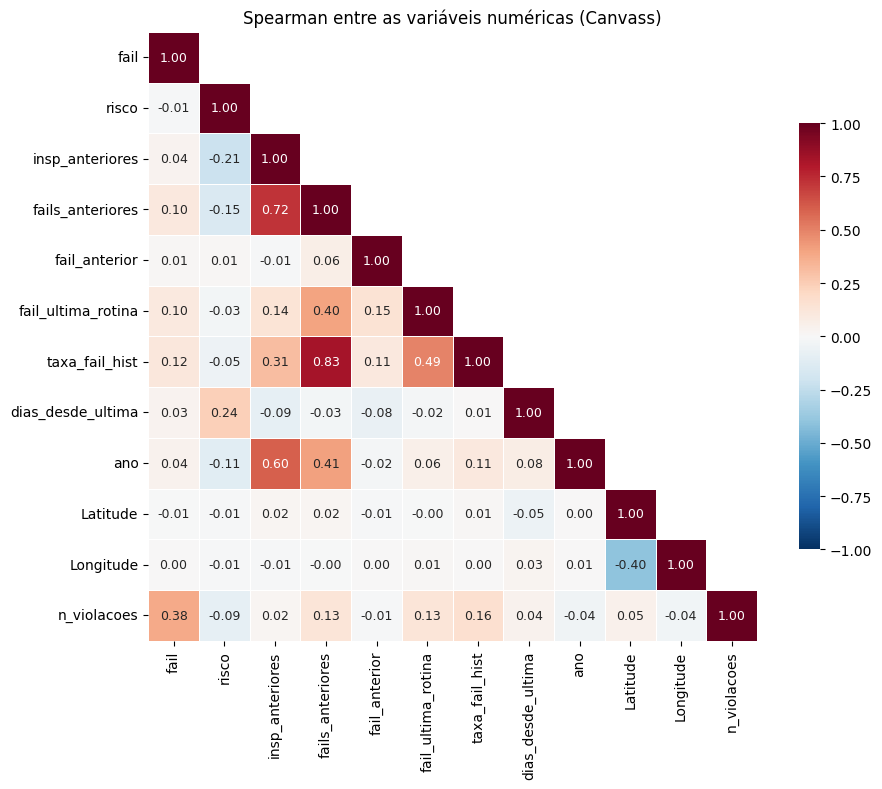

In [ ]:
num = ["fail", "risco", "insp_anteriores", "fails_anteriores", "fail_anterior",
       "fail_ultima_rotina", "taxa_fail_hist",
       "dias_desde_ultima", "ano", "Latitude", "Longitude", "n_violacoes"]
corr = d[num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7},
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Spearman entre as variáveis numéricas (Canvass)")
plt.tight_layout()
plt.savefig(FIGS / "fi-04-spearman.png", dpi=200, bbox_inches="tight")
plt.show()

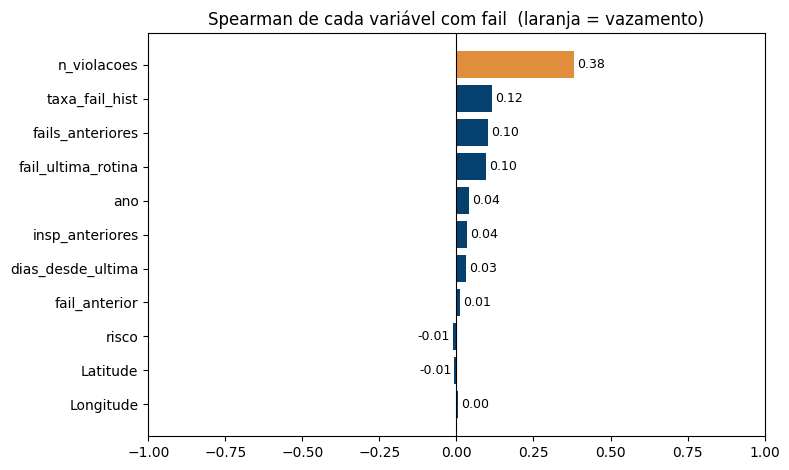

n_violacoes           0.380
taxa_fail_hist        0.116
fails_anteriores      0.104
fail_ultima_rotina    0.097
ano                   0.041
insp_anteriores       0.036
dias_desde_ultima     0.031
fail_anterior         0.013
risco                -0.011
Latitude             -0.007
Longitude             0.004
Name: fail, dtype: float64


In [ ]:
com_alvo = corr["fail"].drop("fail").sort_values(key=abs)
cores = ["#E08D3C" if c == "n_violacoes" else "#06406F" for c in com_alvo.index]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(com_alvo.index, com_alvo.values, color=cores)
ax.axvline(0, color="black", lw=.8)
for i, v in enumerate(com_alvo.values):
    ax.text(v + (.01 if v >= 0 else -.01), i, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlim(-1, 1)
ax.set_title("Spearman de cada variável com fail  (laranja = vazamento)")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-spearman-alvo.png", dpi=200, bbox_inches="tight")
plt.show()

print(com_alvo.sort_values(key=abs, ascending=False).round(3))

### 4.2 · Variáveis categóricas: taxa de Fail por categoria

Para as categóricas, a pergunta é a mesma do `groupby` da a03: **a taxa de Fail muda de uma categoria para outra?** Se a taxa de um grupo fica longe da média geral (linha tracejada), a variável carrega sinal sobre o alvo.

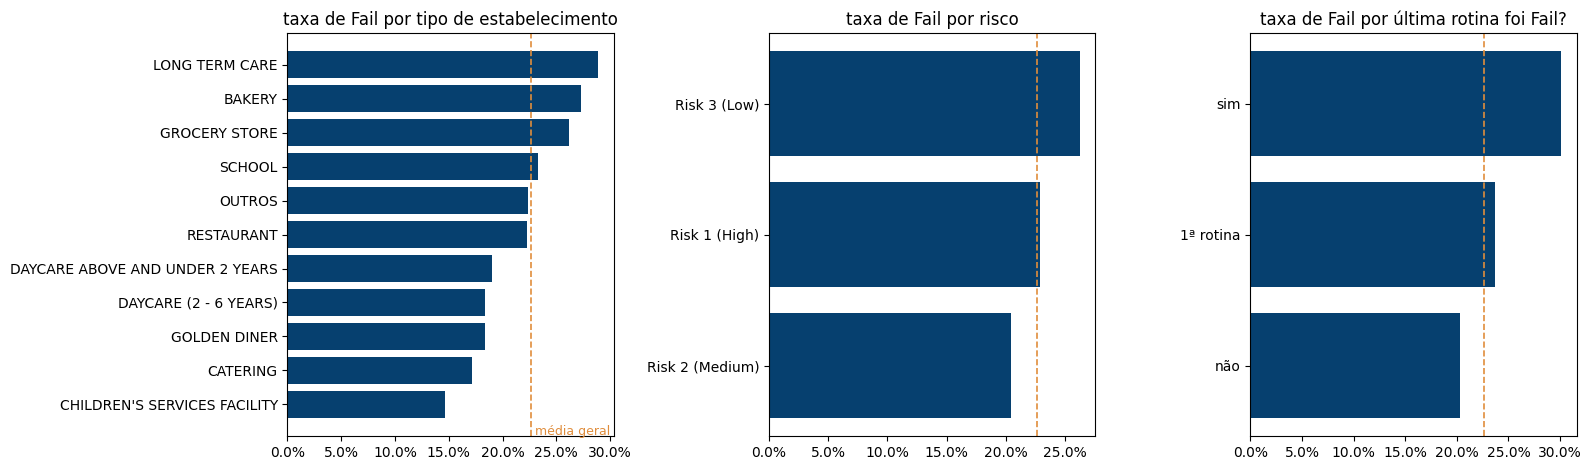


--- tipo de estabelecimento
                                  taxa      n
tipo_estab                                   
LONG TERM CARE                   0.289   1443
BAKERY                           0.273   2056
GROCERY STORE                    0.261  11663
SCHOOL                           0.233  14646
OUTROS                           0.224   4464
RESTAURANT                       0.223  91091
DAYCARE ABOVE AND UNDER 2 YEARS  0.190   1446
DAYCARE (2 - 6 YEARS)            0.184    990
GOLDEN DINER                     0.184    675
CATERING                         0.171    910
CHILDREN'S SERVICES FACILITY     0.147   2704

--- risco
                  taxa       n
risco_txt                     
SEM RISCO        1.000       1
Risk 3 (Low)     0.262    4282
Risk 1 (High)    0.229  108330
Risk 2 (Medium)  0.205   19475

--- última rotina foi Fail?
                     taxa      n
fail_ultima_rotina              
sim                 0.301  22589
1ª rotina           0.237  26871
não            

In [ ]:
# taxa de Fail por categoria: mostra PARA ONDE aponta a associação
taxa_geral = d["fail"].mean()
grupos = {
    "tipo de estabelecimento": d["tipo_estab"],
    "risco": d["risco_txt"],
    "última rotina foi Fail?": d["fail_ultima_rotina"].map({0: "não", 1: "sim"}).fillna("1ª rotina"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (nome, s) in zip(axes, grupos.items()):
    t = d.groupby(s)["fail"].agg(taxa="mean", n="size")
    t = t[t["n"] >= 100].sort_values("taxa")          # categorias com pouco dado ficam de fora
    ax.barh(t.index, t["taxa"], color="#06406F")
    ax.axvline(taxa_geral, color="#E08D3C", ls="--", lw=1.2)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(f"taxa de Fail por {nome}")
    ax.grid(axis="y", alpha=0)
axes[0].text(taxa_geral, -.9, " média geral", color="#E08D3C", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-taxa-fail-categorias.png", dpi=200, bbox_inches="tight")
plt.show()

for nome, s in grupos.items():
    print(f"\n--- {nome}")
    print(d.groupby(s)["fail"].agg(taxa="mean", n="size").sort_values("taxa", ascending=False).round(3))

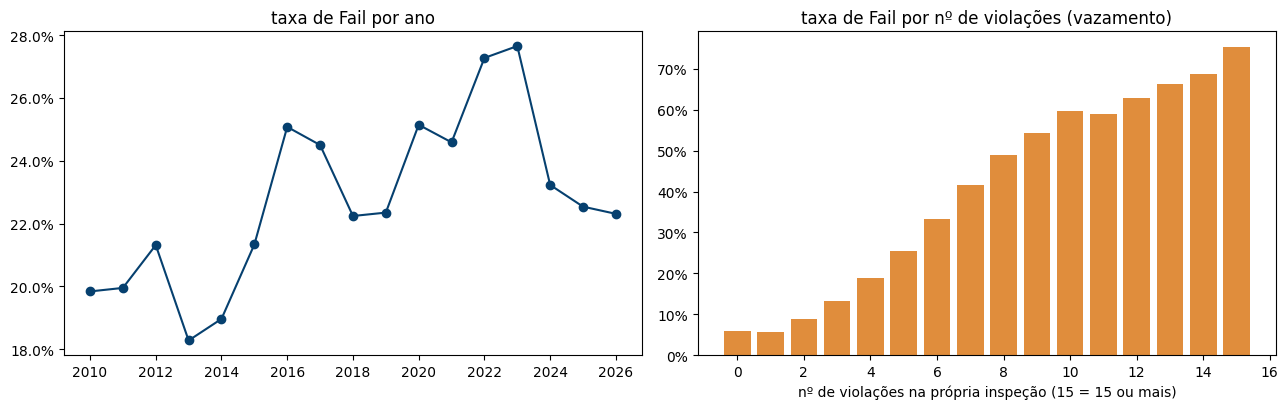

ano
2010    0.198
2011    0.200
2012    0.213
2013    0.183
2014    0.190
2015    0.213
2016    0.251
2017    0.245
2018    0.222
2019    0.224
2020    0.251
2021    0.246
2022    0.273
2023    0.277
2024    0.232
2025    0.225
2026    0.223
Name: fail, dtype: float64


In [ ]:
# tempo e vazamento: como a taxa de Fail muda com o ano e com o nº de violações
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

por_ano = d.groupby("ano")["fail"].mean()
ax1.plot(por_ano.index, por_ano.values, marker="o", color="#06406F")
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_title("taxa de Fail por ano")

por_viol = d.groupby(d["n_violacoes"].clip(upper=15))["fail"].mean()
ax2.bar(por_viol.index, por_viol.values, color="#E08D3C")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.set_xlabel("nº de violações na própria inspeção (15 = 15 ou mais)")
ax2.set_title("taxa de Fail por nº de violações (vazamento)")

plt.tight_layout()
plt.savefig(FIGS / "fi-04-tempo-vazamento.png", dpi=200, bbox_inches="tight")
plt.show()

print(por_ano.round(3))

### 🔬 Aprofundamento: Cramér's V

Os gráficos acima mostram **para onde** aponta cada categoria. Para **comparar a força** da associação entre variáveis diferentes num número só, dá para usar o **Cramér's V** (0 = nenhuma associação, 1 = uma determina a outra). Não é conteúdo da aula: fica como complemento. Usamos a versão com correção de viés, porque colunas com muitas categorias (como `zip`) inflam o V sem correção.

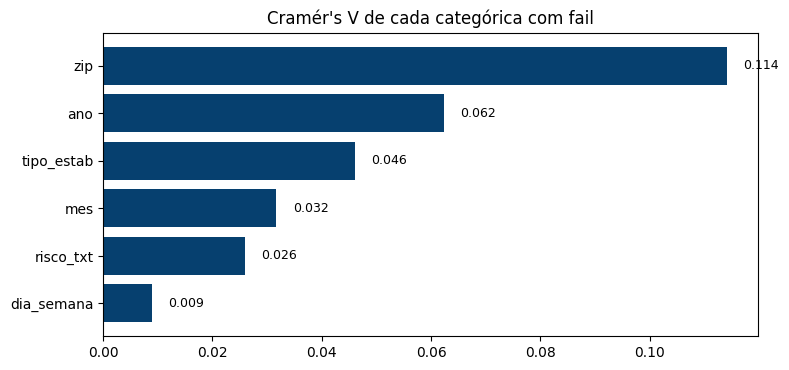

zip           0.114
ano           0.062
tipo_estab    0.046
mes           0.032
risco_txt     0.026
dia_semana    0.009
dtype: float64


In [ ]:
def cramers_v(x, y):
    """Cramér's V com correção de viés (Bergsma, 2013)."""
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum()
    r, k = tab.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_c, k_c = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(k_c - 1, r_c - 1)))

cat = ["tipo_estab", "risco_txt", "zip", "ano", "mes", "dia_semana"]
v_alvo = pd.Series({c: cramers_v(d[c].astype(str), d["fail"]) for c in cat}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(v_alvo.index, v_alvo.values, color="#06406F")
for i, v in enumerate(v_alvo.values):
    ax.text(v + .003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_title("Cramér's V de cada categórica com fail")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-cramer-alvo.png", dpi=200, bbox_inches="tight")
plt.show()

print(v_alvo.sort_values(ascending=False).round(3))

### 4.3 · Redundância entre as categóricas (aprofundamento, Cramér's V)

Se duas variáveis explicativas carregam a mesma informação, manter as duas não ajuda o modelo. Esta matriz é a base da **seleção de features**.

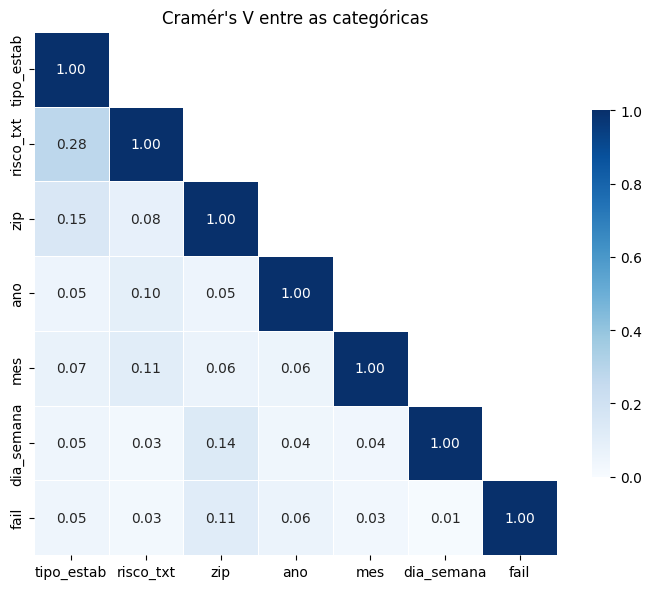

            tipo_estab  risco_txt   zip   ano   mes  dia_semana  fail
tipo_estab        1.00       0.28  0.15  0.05  0.07        0.05  0.05
risco_txt         0.28       1.00  0.08  0.10  0.11        0.03  0.03
zip               0.15       0.08  1.00  0.05  0.06        0.14  0.11
ano               0.05       0.10  0.05  1.00  0.06        0.04  0.06
mes               0.07       0.11  0.06  0.06  1.00        0.04  0.03
dia_semana        0.05       0.03  0.14  0.04  0.04        1.00  0.01
fail              0.05       0.03  0.11  0.06  0.03        0.01  1.00


In [ ]:
cols_v = cat + ["fail"]
mv = pd.DataFrame(np.eye(len(cols_v)), index=cols_v, columns=cols_v)
for i, a in enumerate(cols_v):
    for b in cols_v[i + 1:]:
        mv.loc[a, b] = mv.loc[b, a] = cramers_v(d[a].astype(str), d[b].astype(str))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(mv, mask=np.triu(np.ones_like(mv, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="Blues", vmin=0, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Cramér's V entre as categóricas")
plt.tight_layout()
plt.savefig(FIGS / "fi-04-cramer-matriz.png", dpi=200, bbox_inches="tight")
plt.show()

print(mv.round(2))

### Conclusão da Correlação

Base: **132.088 inspeções Canvass** com resultado sanitário, **22,6% de Fail** (cerca de 1 Fail para cada 3,4 aprovações).

📌 **Nenhuma variável sozinha explica o Fail.** Tirando o vazamento, a maior correlação com o alvo é |ρ| ≈ 0,12. O modelo vai depender de combinações de variáveis, e com o alvo desbalanceado a acurácia sozinha não serve como métrica.

📌 **Vazamento confirmado.** `n_violacoes` tem ρ = 0,38 com `fail`, mais de 3 vezes qualquer outra variável, e a taxa de Fail sobe com o número de violações. A coluna é preenchida durante a própria inspeção.

📌 **O histórico do estabelecimento é o melhor sinal.** `taxa_fail_hist` (0,116), `fails_anteriores` (0,104) e `fail_ultima_rotina` (0,097) lideram. Quando a última rotina foi Fail, a taxa sobe para **30,1%**, contra **20,3%** quando passou (1ª rotina: 23,7%).
Já `fail_anterior` (último registro de qualquer tipo) fica em ≈ 0,01: depois de um Fail vem uma re-inspeção, que em geral passa, e isso apaga o sinal. O que importa é a última **rotina**.

📌 **Redundâncias.** `insp_anteriores` × `fails_anteriores` = 0,72 e `insp_anteriores` × `ano` = 0,60: quanto mais tempo no dataset, mais inspeções acumuladas. `Risk` × `tipo_estab` tem V = 0,28.

📌 **Localização importa, mas não de forma linear.** `zip` é a categórica mais associada (V = 0,114), enquanto Latitude e Longitude têm ρ ≈ 0: o efeito existe por região, não "quanto mais ao norte, mais Fail".

📌 **O tempo muda o alvo.** A taxa de Fail vai de ~19% (2013–2014) a ~27–28% (2022–2023). Isso reforça a decisão da seção 1: dividir treino e teste **por data**.

📌 **Risk é contraintuitivo.** Risk 3 (Low) falha mais (26,2%) que High (22,9%) e Medium (20,5%). `Risk` descreve o tipo de operação e define a frequência de inspeção, não a chance de falhar numa inspeção.

| achado | decisão |
|---|---|
| `n_violacoes` / `Violations` ρ = 0,38 (vazamento) | **não usar** como preditora da mesma inspeção; no máximo, violações da rotina *anterior* |
| histórico: `taxa_fail_hist`, `fails_anteriores`, `fail_ultima_rotina` | **manter**: principais candidatas para a engenharia de features |
| `fail_anterior` ≈ 0,01 | **descartar**, substituída por `fail_ultima_rotina` |
| `insp_anteriores` redundante com `fails_anteriores` (0,72) e `ano` (0,60) | preferir `taxa_fail_hist` e avaliar tirar `insp_anteriores` na seleção |
| `zip` V = 0,114, lat/lon ρ ≈ 0 | usar `zip` (ou agrupamento geográfico); lat/lon cruas não ajudam um modelo linear |
| taxa de Fail muda com o `ano` | divisão treino/teste por data; `ano` pode entrar como feature |
| `tipo_estab` V = 0,046 (14,7% a 28,9%) | **manter** agrupado em top 10 + OUTROS |
| `Risk` fraco e parcialmente redundante com `tipo_estab` | manter por enquanto e decidir na seleção de features |
| `mes` V = 0,032, `dia_semana` V = 0,009 | sinal fraco; `dia_semana` é candidata a descarte |

---
# Conclusão geral da EDA — *o que já sabemos e o que fazer com isso*

As quatro etapas responderam, nesta ordem, a quatro perguntas diferentes sobre o mesmo
arquivo: **de que são feitos estes dados** (estrutura), **dá para confiar neles**
(qualidade), **que forma tem cada variável** (distribuições) e **o que anda junto com o
Fail** (correlação). Cada resposta restringiu a seguinte — e o resultado é um recorte de
modelagem já definido, e não apenas um conjunto de gráficos.

### O caminho, em uma frase por etapa

| etapa | pergunta | o que ficou estabelecido |
|---|---|---|
| **1 · Estrutura** | de que são feitos? | 315.488 linhas × 17 colunas; a linha é **uma inspeção**, não um estabelecimento. `Inspection ID` é chave; `License #` identifica o estabelecimento (49.093 licenças); `Location` e `State` são descartáveis; `Zip`, `License #` e `Inspection Date` estavam com o tipo errado. |
| **2 · Qualidade** | dá para confiar? | Boa integridade: sem duplicatas exatas, sem `Inspection ID` repetido, sem data inválida ou futura, sem CEP/coordenada impossível. 12 das 17 colunas têm vazios; o maior é `Violations` (28,19%), e ele é **estrutural**, não aleatório. |
| **3 · Distribuições** | que forma têm? | O alvo é desbalanceado e "sujo": 4 dos 7 valores de `Results` descrevem inspeção que não aconteceu. Contagens por estabelecimento são **assimétricas** (média 6,41 vs. mediana 3, skew 2,59) e `Facility Type` tem cauda longa (486 dos 527 tipos com menos de 50 linhas). |
| **4 · Correlação** | o que anda junto? | Nenhuma variável sozinha explica o Fail (maior \|ρ\| ≈ 0,12 fora o vazamento). O **histórico do estabelecimento** é o melhor sinal; `n_violacoes` é **vazamento** (ρ = 0,38); a taxa de Fail **cresce ao longo dos anos**. |

### As três conclusões que atravessam as quatro etapas

📌 **1. A unidade da linha determina a validação.** A etapa 1 mostrou que o mesmo
estabelecimento aparece em várias linhas (mediana de 3 inspeções por licença) e a etapa 4
mostrou que a taxa de Fail sobe de ~19% (2013–2014) para ~27–28% (2022–2023). As duas
apontam para a mesma decisão: **divisão treino/teste por data** (ou por licença), nunca
aleatória — um split aleatório vaza o passado de um estabelecimento para dentro do teste e
mistura períodos com taxas de Fail diferentes.

📌 **2. O alvo teve de ser construído, não apenas escolhido.** `Results` parecia o alvo
pronto na etapa 1, mas as etapas 2 e 3 mostraram que `Out of Business`, `No Entry`,
`Not Ready` e `Business Not Located` (≈44,6 mil linhas) descrevem inspeções que **não
ocorreram** — inclusive é nelas que `Violations` está quase sempre vazio, o que confirma
que o vazio é "não se aplica". Somando o recorte de `Inspection Type` (`Canvass` = 51% das
linhas, a inspeção de rotina), chegou-se à base efetiva da etapa 4: **132.088 inspeções
Canvass com resultado sanitário, 22,6% de Fail**.

📌 **3. Nem toda coluna disponível é utilizável.** Três motivos diferentes eliminam
colunas: **redundância** (`Location` = `Latitude`+`Longitude`; `insp_anteriores` × `fails_anteriores` = 0,72),
**ausência de variação** (`State` é `IL` em 315.389 de 315.488 linhas) e, o mais importante,
**vazamento temporal** (`Violations` é preenchida *durante* a inspeção que queremos prever).
A etapa 4 mediu o vazamento em vez de supô-lo: ρ = 0,38, mais de três vezes qualquer
preditora legítima.

### Onde chegamos — o recorte e as features candidatas

| item | definição fechada |
|---|---|
| **base de modelagem** | inspeções `Canvass` com `Results` ∈ {Pass, Pass w/ Conditions, Fail} → **132.088 linhas** |
| **alvo** | `fail = 1` se `Results == "Fail"` — **22,6% de positivos** (desbalanceado) |
| **validação** | split **temporal**; acurácia não serve como métrica única |
| **manter (melhor sinal)** | `taxa_fail_hist` (0,116), `fails_anteriores` (0,104), `fail_ultima_rotina` (0,097) |
| **manter (com tratamento)** | `zip` (V = 0,114), `tipo_estab` agrupado em top 10 + OUTROS, `ano`, `Risk` (decidir na seleção) |
| **descartar** | `Location`, `State`, `fail_anterior` (≈ 0,01), `Violations`/`n_violacoes` como preditora da inspeção atual |
| **limpezas pendentes** | `License #` = 0 → ausente; `City` normalizada; `Risk` = `All` (85–86 linhas) tratado à parte; `Zip` e `License #` como texto |

### Premissas e riscos que ficam em aberto

- **Contagem de linhas.** A etapa 1 leu 315.488 linhas e a etapa 2, 315.560. O arquivo é
  baixado direto do portal a cada execução, então ele **muda entre rodadas**. Antes de
  fechar o relatório, fixar uma extração (salvar o CSV com data) para que todos os números
  se refiram à mesma base.
- **Dicionário oficial não conferido.** As descrições das colunas foram inferidas dos nomes
  e dos valores; o dicionário do Chicago Data Portal ainda precisa ser confrontado.
- **2.755 linhas com mesma licença + data + tipo** não foram removidas: podem ser
  inspeções legítimas ou estabelecimentos distintos sob a mesma licença. Continua em aberto.
- **`Risk` é contraintuitivo** (Low falha mais que High): ele descreve o tipo de operação e
  a frequência de inspeção, não a probabilidade de falhar. Usar sem essa leitura leva a
  interpretação errada do modelo.
- **5.341 ausências em `Facility Type`** ainda não foram investigadas antes de qualquer
  preenchimento.

### Próximos passos

1. Congelar uma extração datada do CSV e reexecutar as quatro etapas sobre ela.
2. Aplicar as limpezas decididas (tipos, normalizações, `License #` = 0, descartes) num
   único bloco de preparação reprodutível.
3. Construir as features de histórico **estritamente com dados anteriores** a cada inspeção,
   para não reintroduzir vazamento.
4. Montar o split temporal e um baseline (classe majoritária + regressão logística),
   avaliando por precisão/recall/PR-AUC em vez de acurácia.
5. Rodar a seleção de features usando a matriz de redundância da etapa 4.